# Notebook 11 — Máquinas de Vectores de Soporte y kernels

En este notebook estudiaremos cómo las Máquinas de Vectores de Soporte (SVM) construyen fronteras de decisión de margen máximo y cómo los kernels permiten modelar relaciones no lineales.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar la idea de hiperplano y margen;
- identificar los vectores de soporte;
- ajustar una SVM lineal;
- interpretar el hiperparámetro \(C\);
- comprender por qué el escalamiento es importante;
- utilizar kernels polinomial y RBF;
- interpretar el hiperparámetro \(\gamma\);
- comparar fronteras lineales y no lineales;
- evaluar SVM con métricas de clasificación;
- reconocer sus principales ventajas y limitaciones.

Usaremos datasets sintéticos generados con `make_blobs`, `make_moons` y `make_circles`.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42

pd.options.display.float_format = "{:,.4f}".format


## 2. Función auxiliar para visualizar fronteras de decisión

In [2]:
def plot_decision_boundary(
    model,
    X,
    y,
    title,
    support_vectors=None,
):
    """Visualiza la frontera de decisión de un clasificador bidimensional."""

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500),
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    prediction_grid = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(9, 7))
    plt.contourf(xx, yy, prediction_grid, alpha=0.25)

    for class_value in np.unique(y):
        mask = y == class_value
        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            alpha=0.75,
            label=f"Clase {class_value}",
        )

    if support_vectors is not None:
        plt.scatter(
            support_vectors[:, 0],
            support_vectors[:, 1],
            s=180,
            facecolors="none",
            edgecolors="black",
            linewidths=1.5,
            label="Vectores de soporte",
        )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


# Parte I. SVM lineal

## 3. Datos linealmente separables

Una SVM lineal busca un hiperplano que separe las clases maximizando el margen.

En dos dimensiones, el hiperplano es una recta.

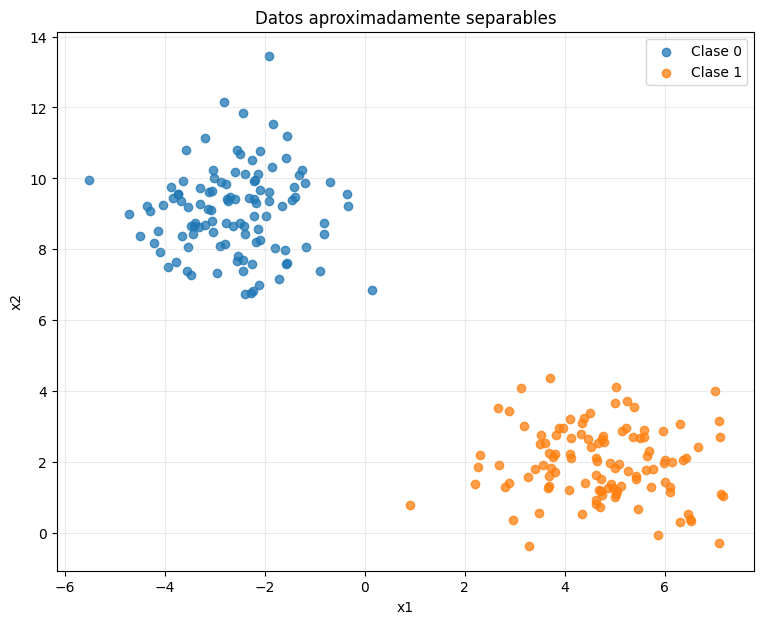

In [3]:
X_linear, y_linear = make_blobs(
    n_samples=220,
    centers=2,
    n_features=2,
    cluster_std=1.15,
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(9, 7))

for class_value in np.unique(y_linear):
    mask = y_linear == class_value
    plt.scatter(
        X_linear[mask, 0],
        X_linear[mask, 1],
        alpha=0.75,
        label=f"Clase {class_value}",
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Datos aproximadamente separables")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 4. Ajuste de una SVM lineal

Usaremos `SVC(kernel="linear")`.

In [4]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_linear,
    y_linear,
    test_size=0.25,
    stratify=y_linear,
    random_state=RANDOM_STATE,
)

linear_svm = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svm",
        SVC(
            kernel="linear",
            C=1.0,
            probability=True,
            random_state=RANDOM_STATE,
        ),
    ),
])

linear_svm.fit(
    X_train_lin,
    y_train_lin,
)

linear_predictions = linear_svm.predict(
    X_test_lin
)

linear_probabilities = linear_svm.predict_proba(
    X_test_lin
)[:, 1]

pd.DataFrame({
    "Métrica": ["Accuracy", "F1", "ROC-AUC"],
    "Valor": [
        accuracy_score(
            y_test_lin,
            linear_predictions,
        ),
        f1_score(
            y_test_lin,
            linear_predictions,
        ),
        roc_auc_score(
            y_test_lin,
            linear_probabilities,
        ),
    ],
})


,Métrica,Valor
0,Accuracy,1.0000
1,F1,1.0000
2,ROC-AUC,1.0000


## 5. Vectores de soporte

Los vectores de soporte son las observaciones que determinan la posición del margen y de la frontera.

Las observaciones alejadas del margen no modifican directamente la solución.

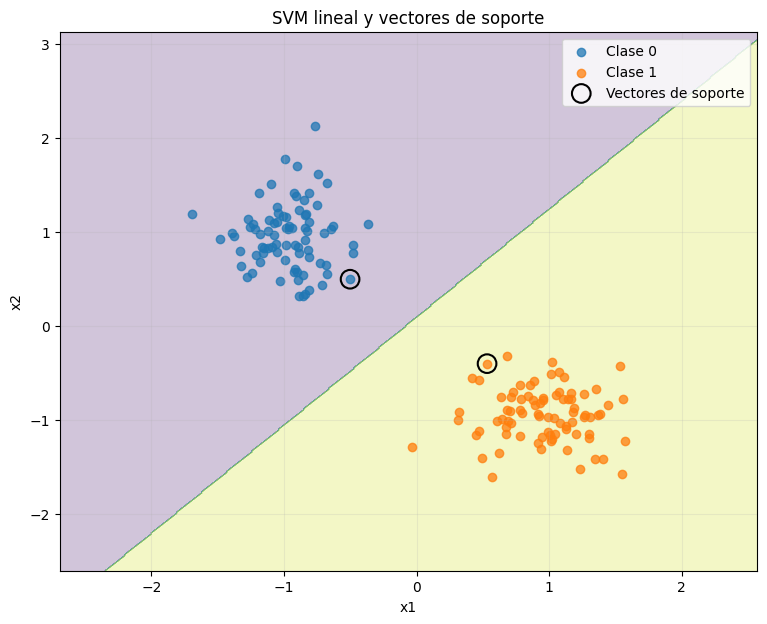

In [5]:
scaler_linear = linear_svm.named_steps["scaler"]
svm_linear_step = linear_svm.named_steps["svm"]

X_train_lin_scaled = scaler_linear.transform(
    X_train_lin
)

support_vectors_scaled = svm_linear_step.support_vectors_

plot_decision_boundary(
    svm_linear_step,
    X_train_lin_scaled,
    y_train_lin,
    title="SVM lineal y vectores de soporte",
    support_vectors=support_vectors_scaled,
)


In [6]:
print(
    "Número total de vectores de soporte:",
    len(svm_linear_step.support_),
)

print(
    "Vectores de soporte por clase:",
    svm_linear_step.n_support_,
)


Número total de vectores de soporte: 2
Vectores de soporte por clase: [1 1]


## 6. El hiperparámetro \(C\)

\(C\) controla la penalización de los errores de clasificación.

- \(C\) pequeño: margen más amplio y mayor tolerancia a errores;
- \(C\) grande: intenta clasificar correctamente más observaciones, con una frontera más rígida.

Esto refleja un compromiso entre margen y ajuste.

In [7]:
c_values = [0.01, 0.1, 1, 10, 100]
c_results = []

for c_value in c_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="linear",
                C=c_value,
                probability=True,
                random_state=RANDOM_STATE,
            ),
        ),
    ])

    model.fit(
        X_train_lin,
        y_train_lin,
    )

    train_pred = model.predict(
        X_train_lin
    )
    test_pred = model.predict(
        X_test_lin
    )

    c_results.append({
        "C": c_value,
        "Accuracy train": accuracy_score(
            y_train_lin,
            train_pred,
        ),
        "Accuracy test": accuracy_score(
            y_test_lin,
            test_pred,
        ),
        "Vectores de soporte": len(
            model.named_steps["svm"].support_
        ),
    })

c_results_df = pd.DataFrame(
    c_results
)

c_results_df


,C,Accuracy train,Accuracy test,Vectores de soporte
0,0.0100,1.0000,1.0000,72
1,0.1000,1.0000,1.0000,14
2,1.0000,1.0000,1.0000,2
3,10.0000,1.0000,1.0000,2
4,100.0000,1.0000,1.0000,2


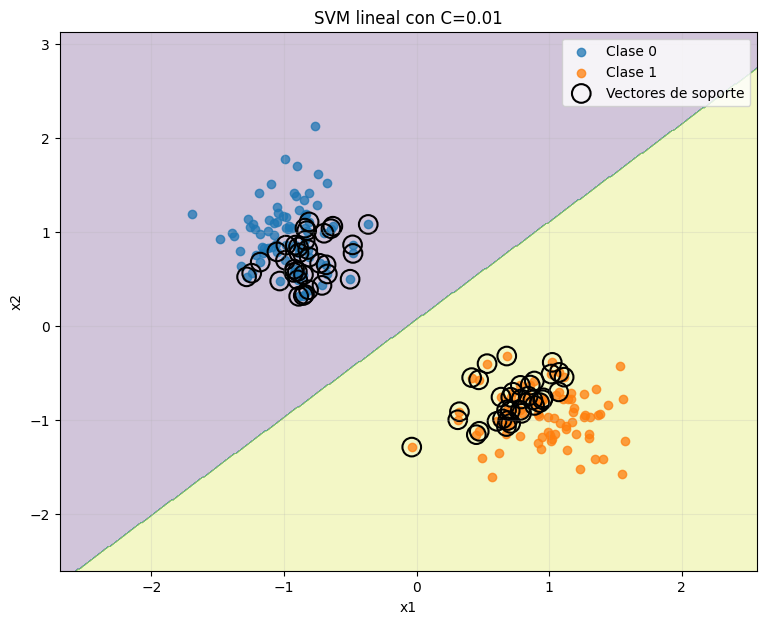

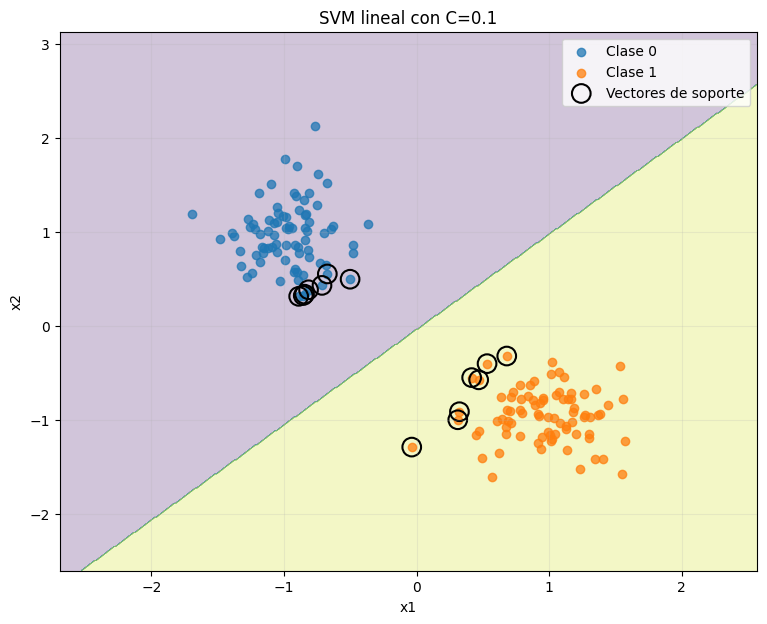

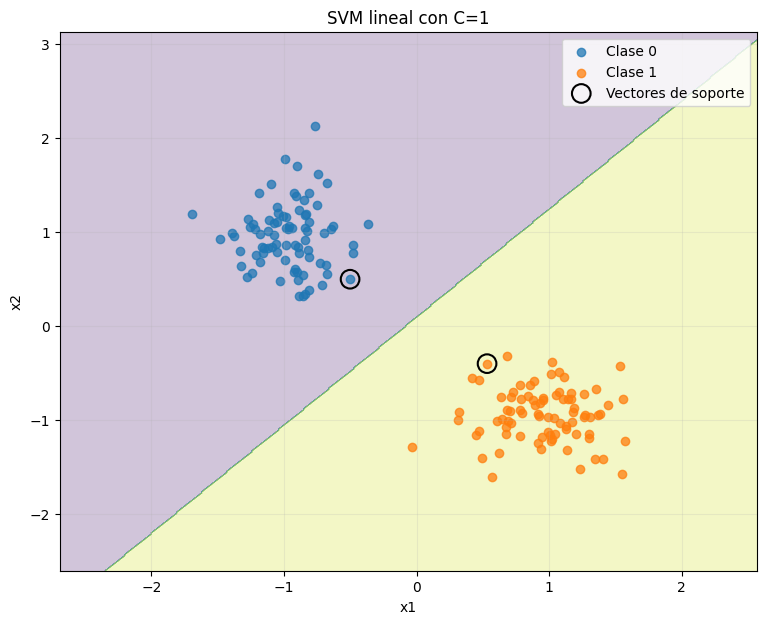

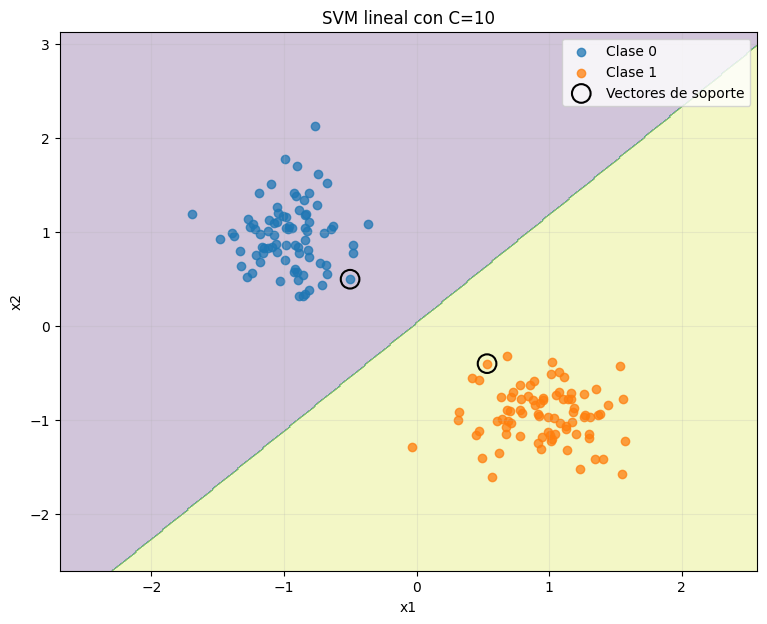

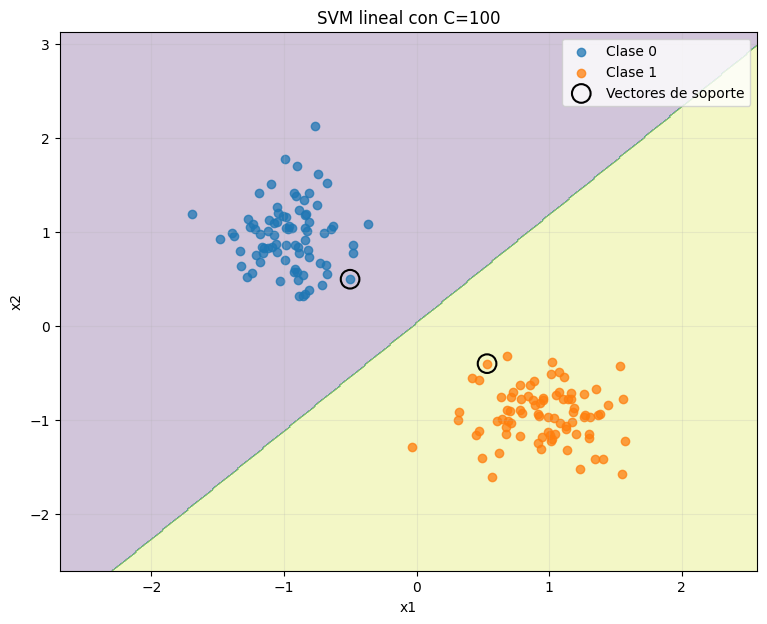

In [8]:
for c_value in c_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="linear",
                C=c_value,
                random_state=RANDOM_STATE,
            ),
        ),
    ])

    model.fit(
        X_train_lin,
        y_train_lin,
    )

    scaler_step = model.named_steps["scaler"]
    svm_step = model.named_steps["svm"]

    X_train_scaled = scaler_step.transform(
        X_train_lin
    )

    plot_decision_boundary(
        svm_step,
        X_train_scaled,
        y_train_lin,
        title=f"SVM lineal con C={c_value}",
        support_vectors=svm_step.support_vectors_,
    )


# Parte II. Importancia del escalamiento

## 7. Variables en escalas diferentes

SVM depende de productos internos y distancias. Una variable con escala mucho mayor puede dominar el ajuste.

In [9]:
X_scale = X_linear.copy()
X_scale[:, 1] = X_scale[:, 1] * 1_000

X_train_scale, X_test_scale, y_train_scale, y_test_scale = (
    train_test_split(
        X_scale,
        y_linear,
        test_size=0.25,
        stratify=y_linear,
        random_state=RANDOM_STATE,
    )
)

svm_without_scaling = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
)

svm_with_scaling = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=1,
            gamma="scale",
        ),
    ),
])

svm_without_scaling.fit(
    X_train_scale,
    y_train_scale,
)

svm_with_scaling.fit(
    X_train_scale,
    y_train_scale,
)

scale_comparison = pd.DataFrame({
    "Modelo": [
        "SVM sin escalamiento",
        "SVM con escalamiento",
    ],
    "Accuracy test": [
        accuracy_score(
            y_test_scale,
            svm_without_scaling.predict(
                X_test_scale
            ),
        ),
        accuracy_score(
            y_test_scale,
            svm_with_scaling.predict(
                X_test_scale
            ),
        ),
    ],
})

scale_comparison


,Modelo,Accuracy test
0,SVM sin escalamiento,1.0000
1,SVM con escalamiento,1.0000


El escalamiento debe permanecer dentro de un `Pipeline` para evitar Data Leakage.

# Parte III. Kernels no lineales

## 8. Datos con forma de lunas

Una frontera lineal no puede separar adecuadamente este patrón.

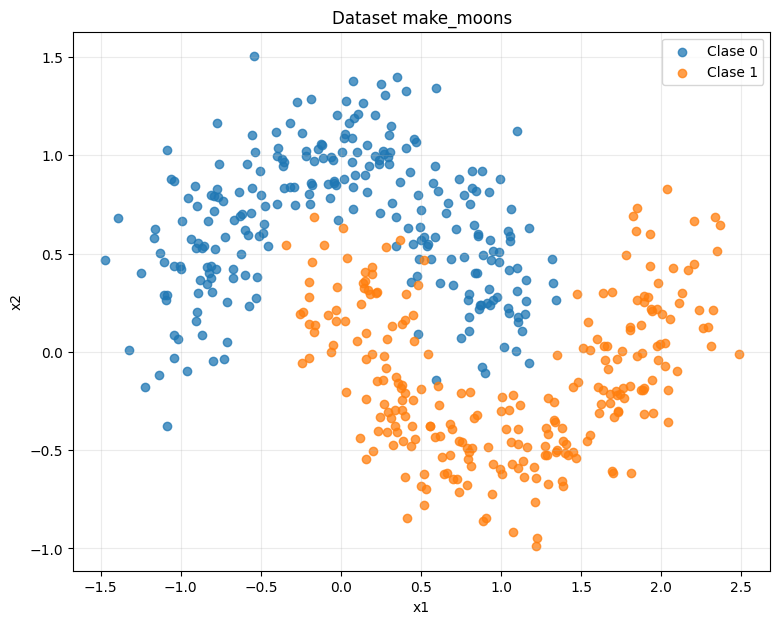

In [10]:
X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.20,
    random_state=RANDOM_STATE,
)

X_train_moon, X_test_moon, y_train_moon, y_test_moon = (
    train_test_split(
        X_moons,
        y_moons,
        test_size=0.25,
        stratify=y_moons,
        random_state=RANDOM_STATE,
    )
)

plt.figure(figsize=(9, 7))

for class_value in np.unique(y_moons):
    mask = y_moons == class_value
    plt.scatter(
        X_moons[mask, 0],
        X_moons[mask, 1],
        alpha=0.75,
        label=f"Clase {class_value}",
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset make_moons")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 9. Comparación de kernels

Compararemos:

- lineal;
- polinomial;
- RBF.

In [11]:
kernel_models = {
    "Lineal": Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="linear",
                C=1,
            ),
        ),
    ]),
    "Polinomial": Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="poly",
                degree=3,
                C=1,
                gamma="scale",
            ),
        ),
    ]),
    "RBF": Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=1,
                gamma="scale",
            ),
        ),
    ]),
}

kernel_results = []

for model_name, model in kernel_models.items():
    model.fit(
        X_train_moon,
        y_train_moon,
    )

    train_pred = model.predict(
        X_train_moon
    )
    test_pred = model.predict(
        X_test_moon
    )

    kernel_results.append({
        "Kernel": model_name,
        "Accuracy train": accuracy_score(
            y_train_moon,
            train_pred,
        ),
        "Accuracy test": accuracy_score(
            y_test_moon,
            test_pred,
        ),
        "F1 test": f1_score(
            y_test_moon,
            test_pred,
        ),
        "Vectores de soporte": len(
            model.named_steps["svm"].support_
        ),
    })

kernel_results_df = pd.DataFrame(
    kernel_results
)

kernel_results_df


,Kernel,Accuracy train,Accuracy test,F1 test,Vectores de soporte
0,Lineal,0.8613,0.8560,0.8525,115
1,Polinomial,0.8640,0.8400,0.8361,115
2,RBF,0.9680,0.9840,0.9836,84


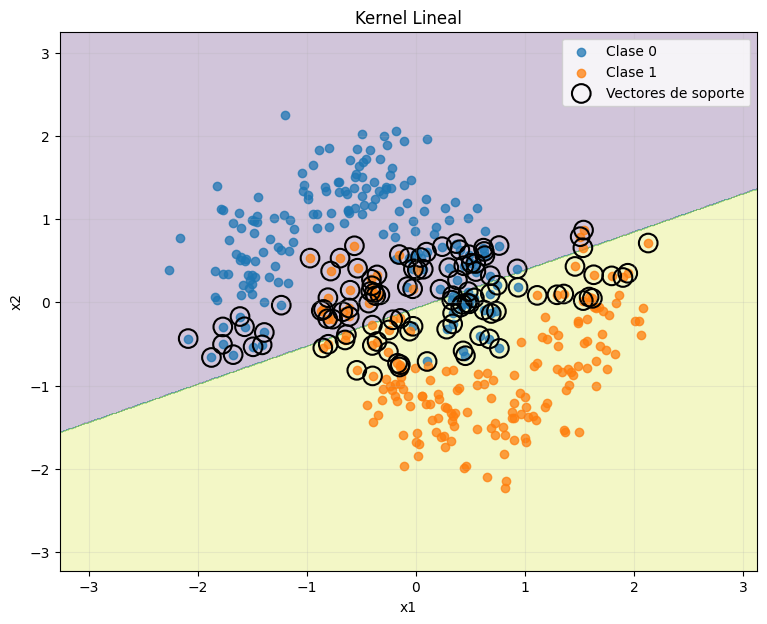

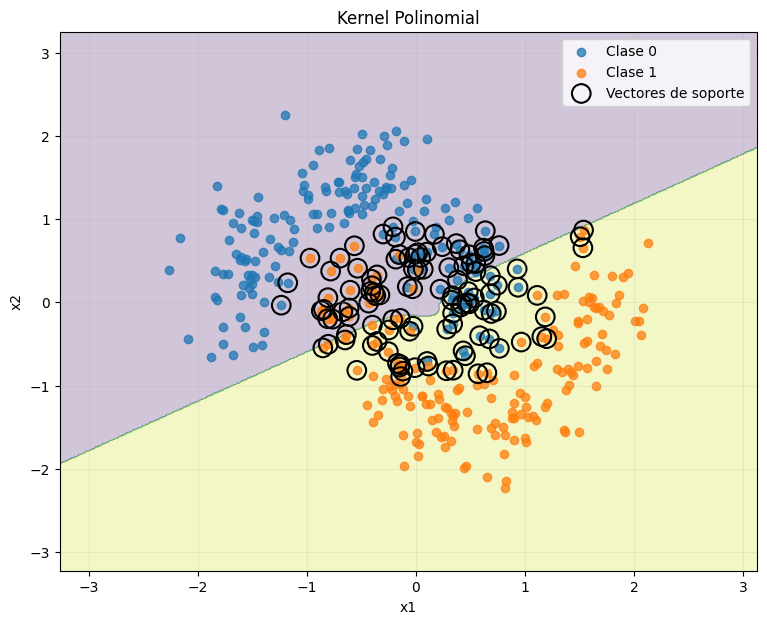

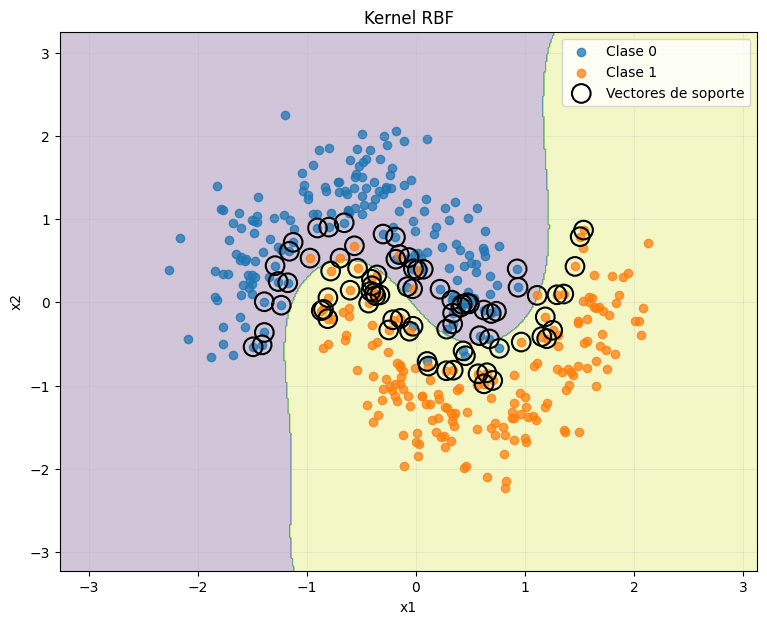

In [12]:
for model_name, model in kernel_models.items():
    scaler_step = model.named_steps["scaler"]
    svm_step = model.named_steps["svm"]

    X_train_scaled = scaler_step.transform(
        X_train_moon
    )

    plot_decision_boundary(
        svm_step,
        X_train_scaled,
        y_train_moon,
        title=f"Kernel {model_name}",
        support_vectors=svm_step.support_vectors_,
    )


## 10. Intuición del kernel

Un kernel permite calcular similitudes como si los datos se hubieran proyectado a un espacio de mayor dimensión, sin construir explícitamente todas las nuevas variables.

Esto se conoce como **kernel trick**.

El kernel RBF es especialmente flexible para fronteras locales y curvas.

# Parte IV. Efecto de \(\gamma\)

## 11. Kernel RBF y gamma

\(\gamma\) controla el alcance de influencia de cada observación.

- \(\gamma\) pequeño: influencia amplia y frontera suave;
- \(\gamma\) grande: influencia local y frontera más compleja.

In [13]:
gamma_values = [0.01, 0.1, 1, 10, 100]
gamma_results = []

for gamma_value in gamma_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=10,
                gamma=gamma_value,
            ),
        ),
    ])

    model.fit(
        X_train_moon,
        y_train_moon,
    )

    train_pred = model.predict(
        X_train_moon
    )
    test_pred = model.predict(
        X_test_moon
    )

    gamma_results.append({
        "Gamma": gamma_value,
        "Accuracy train": accuracy_score(
            y_train_moon,
            train_pred,
        ),
        "Accuracy test": accuracy_score(
            y_test_moon,
            test_pred,
        ),
        "Vectores de soporte": len(
            model.named_steps["svm"].support_
        ),
    })

gamma_results_df = pd.DataFrame(
    gamma_results
)

gamma_results_df


,Gamma,Accuracy train,Accuracy test,Vectores de soporte
0,0.0100,0.8640,0.8400,125
1,0.1000,0.9253,0.9360,104
2,1.0000,0.9840,0.9920,31
3,10.0000,0.9867,0.9760,127
4,100.0000,0.9973,0.9280,334


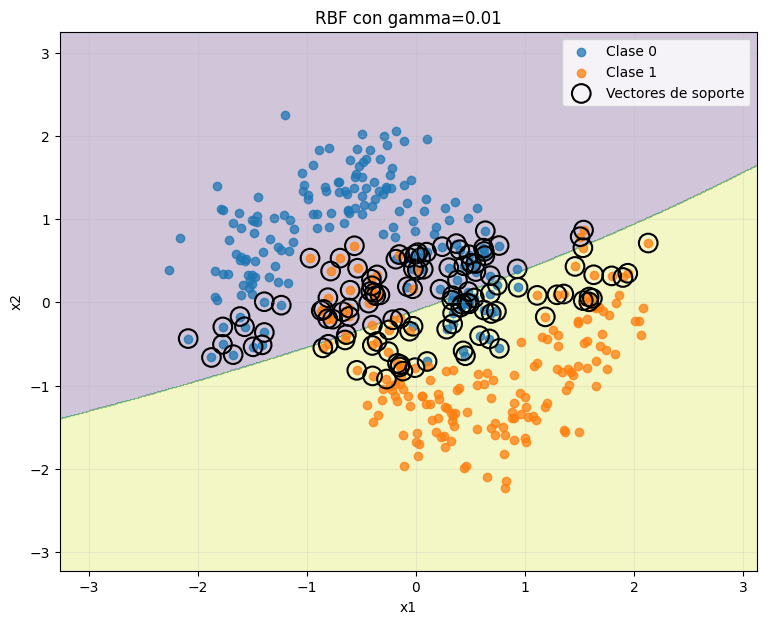

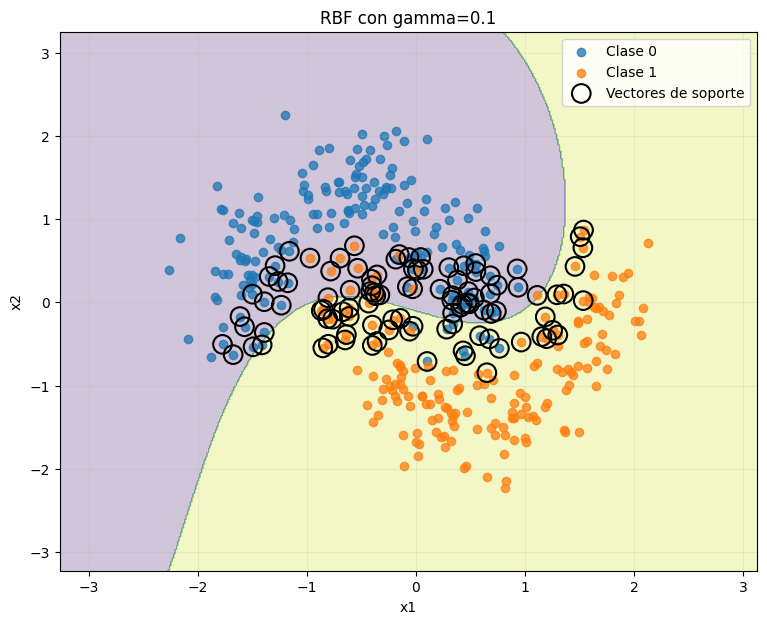

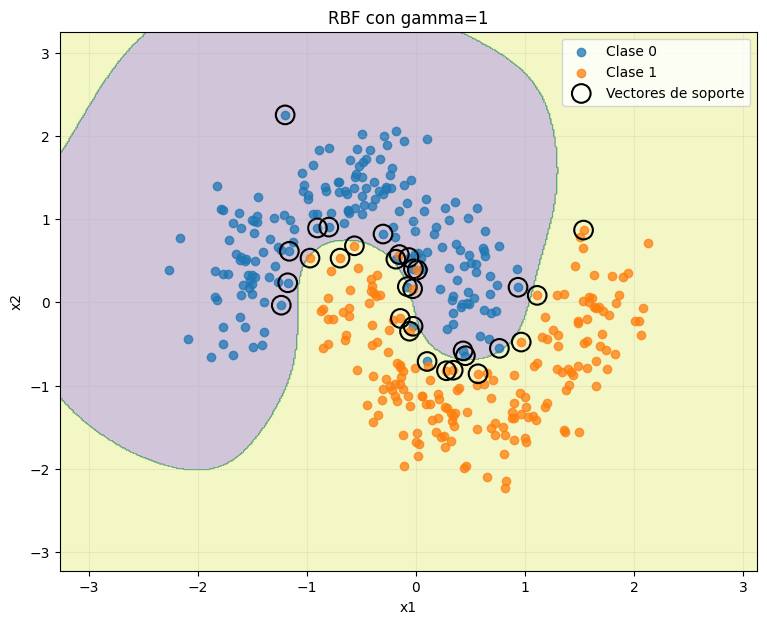

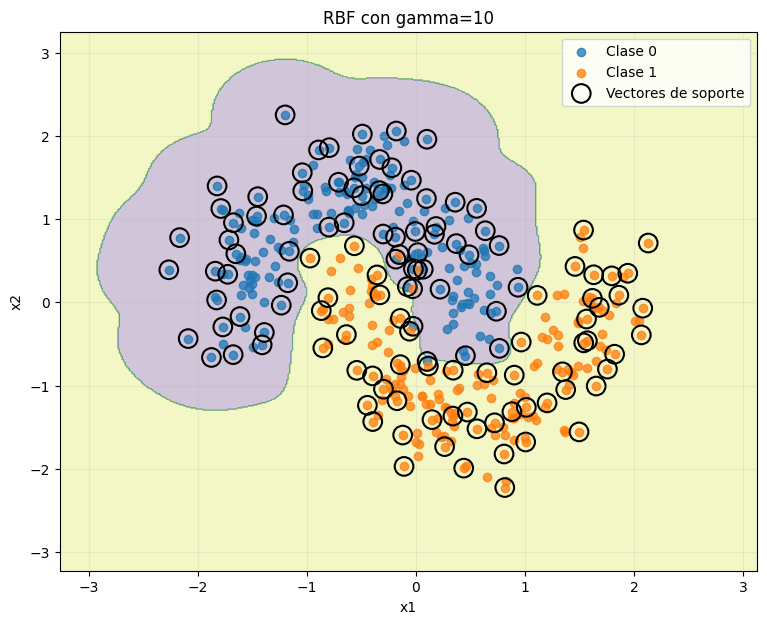

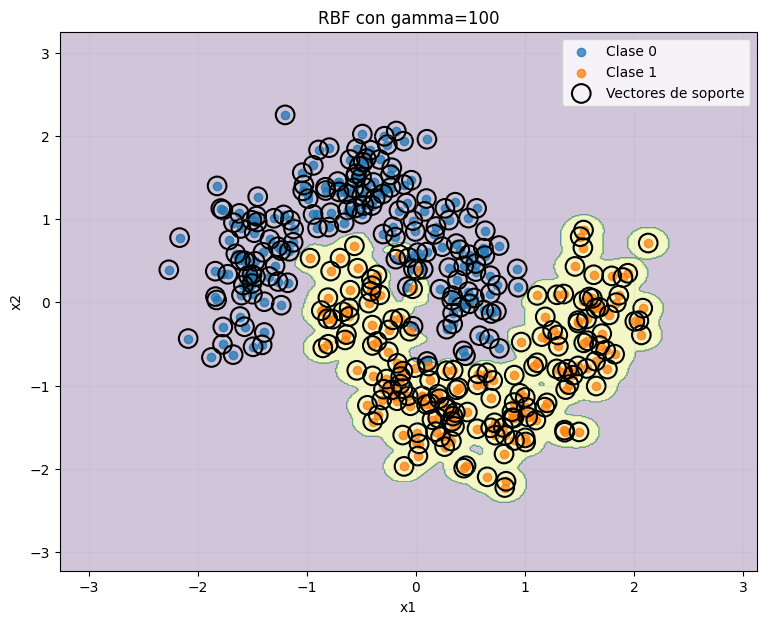

In [14]:
for gamma_value in gamma_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=10,
                gamma=gamma_value,
            ),
        ),
    ])

    model.fit(
        X_train_moon,
        y_train_moon,
    )

    scaler_step = model.named_steps["scaler"]
    svm_step = model.named_steps["svm"]

    X_train_scaled = scaler_step.transform(
        X_train_moon
    )

    plot_decision_boundary(
        svm_step,
        X_train_scaled,
        y_train_moon,
        title=f"RBF con gamma={gamma_value}",
        support_vectors=svm_step.support_vectors_,
    )


Un \(\gamma\) excesivamente alto puede producir overfitting.  
Un \(\gamma\) demasiado bajo puede producir underfitting.

# Parte V. Interacción entre \(C\) y \(\gamma\)

## 12. Malla de configuraciones

En RBF, \(C\) y \(\gamma\) deben interpretarse conjuntamente.

In [15]:
parameter_rows = []

for c_value in [0.1, 1, 10, 100]:
    for gamma_value in [0.01, 0.1, 1, 10]:
        model = Pipeline([
            ("scaler", StandardScaler()),
            (
                "svm",
                SVC(
                    kernel="rbf",
                    C=c_value,
                    gamma=gamma_value,
                ),
            ),
        ])

        model.fit(
            X_train_moon,
            y_train_moon,
        )

        train_pred = model.predict(
            X_train_moon
        )
        test_pred = model.predict(
            X_test_moon
        )

        parameter_rows.append({
            "C": c_value,
            "Gamma": gamma_value,
            "Accuracy train": accuracy_score(
                y_train_moon,
                train_pred,
            ),
            "Accuracy test": accuracy_score(
                y_test_moon,
                test_pred,
            ),
        })

parameter_table = pd.DataFrame(
    parameter_rows
)

parameter_table


,C,Gamma,Accuracy train,Accuracy test
0,0.1000,0.0100,0.8427,0.8480
1,0.1000,0.1000,0.8640,0.8560
2,0.1000,1.0000,0.9547,0.9760
3,0.1000,10.0000,0.9787,0.9680
4,1.0000,0.0100,0.8587,0.8640
5,1.0000,0.1000,0.8773,0.8480
6,1.0000,1.0000,0.9760,0.9840
7,1.0000,10.0000,0.9867,0.9840
8,10.0000,0.0100,0.8640,0.8400
9,10.0000,0.1000,0.9253,0.9360


In [16]:
accuracy_pivot = parameter_table.pivot(
    index="Gamma",
    columns="C",
    values="Accuracy test",
)

accuracy_pivot


C,0.1000,1.0000,10.0000,100.0000
Gamma,,,,
0.0100,0.8480,0.8640,0.8400,0.8320
0.1000,0.8560,0.8480,0.9360,0.9760
1.0000,0.9760,0.9840,0.9920,0.9840
10.0000,0.9680,0.9840,0.9760,0.9280


La selección formal debe realizarse con validación cruzada, no observando repetidamente test.

# Parte VI. Dataset de círculos

## 13. Una frontera radial

`make_circles` muestra otro caso donde un kernel lineal no es suficiente.

In [17]:
X_circles, y_circles = make_circles(
    n_samples=600,
    factor=0.45,
    noise=0.10,
    random_state=RANDOM_STATE,
)

X_train_circle, X_test_circle, y_train_circle, y_test_circle = (
    train_test_split(
        X_circles,
        y_circles,
        test_size=0.25,
        stratify=y_circles,
        random_state=RANDOM_STATE,
    )
)

circle_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1)),
])

circle_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma=1)),
])

circle_linear.fit(
    X_train_circle,
    y_train_circle,
)

circle_rbf.fit(
    X_train_circle,
    y_train_circle,
)

circle_comparison = pd.DataFrame({
    "Modelo": ["Lineal", "RBF"],
    "Accuracy test": [
        accuracy_score(
            y_test_circle,
            circle_linear.predict(
                X_test_circle
            ),
        ),
        accuracy_score(
            y_test_circle,
            circle_rbf.predict(
                X_test_circle
            ),
        ),
    ],
})

circle_comparison


,Modelo,Accuracy test
0,Lineal,0.5600
1,RBF,1.0000


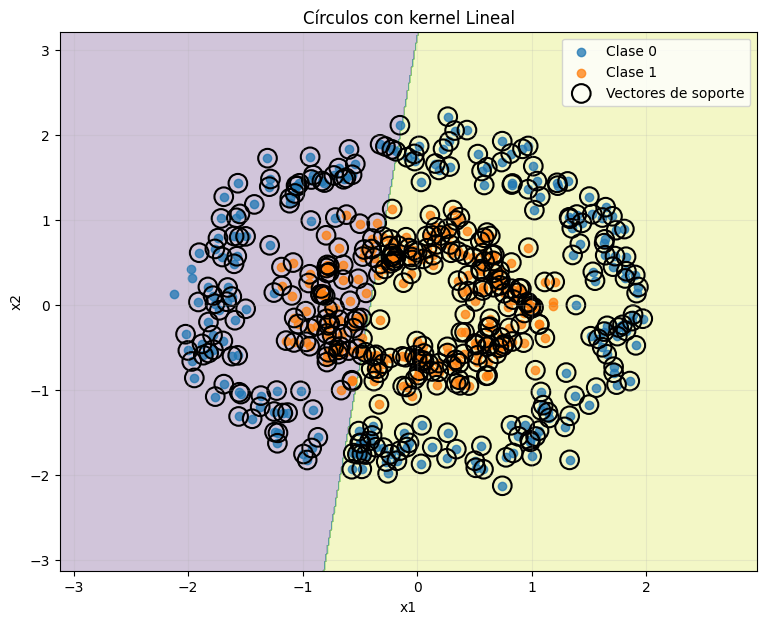

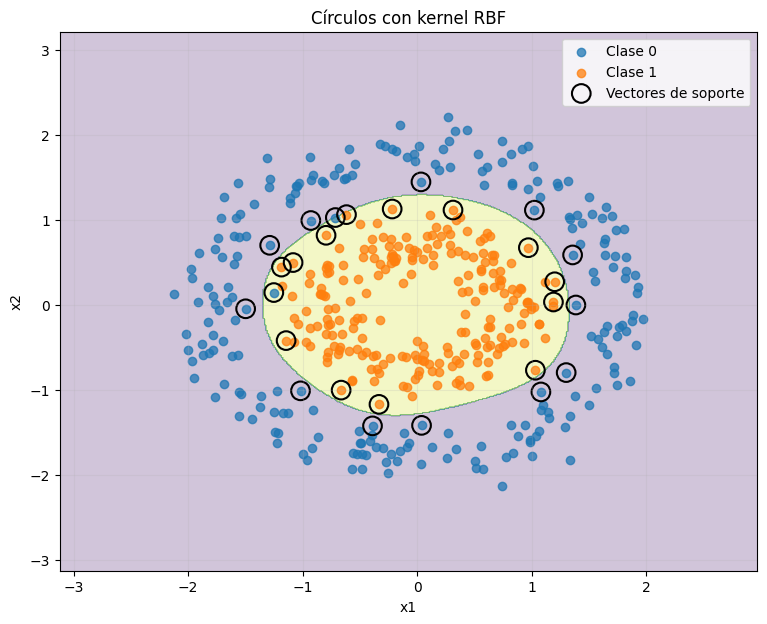

In [18]:
for model_name, model in {
    "Lineal": circle_linear,
    "RBF": circle_rbf,
}.items():
    scaler_step = model.named_steps["scaler"]
    svm_step = model.named_steps["svm"]

    X_train_scaled = scaler_step.transform(
        X_train_circle
    )

    plot_decision_boundary(
        svm_step,
        X_train_scaled,
        y_train_circle,
        title=f"Círculos con kernel {model_name}",
        support_vectors=svm_step.support_vectors_,
    )


## 14. Evaluación completa del mejor modelo

Usaremos la SVM RBF sobre `make_moons`.

In [19]:
best_svm = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=10,
            gamma=1,
            probability=True,
            random_state=RANDOM_STATE,
        ),
    ),
])

best_svm.fit(
    X_train_moon,
    y_train_moon,
)

best_predictions = best_svm.predict(
    X_test_moon
)

best_probabilities = best_svm.predict_proba(
    X_test_moon
)[:, 1]

print(
    classification_report(
        y_test_moon,
        best_predictions,
        digits=4,
    )
)


              precision    recall  f1-score   support

           0     0.9844    1.0000    0.9921        63
           1     1.0000    0.9839    0.9919        62

    accuracy                         0.9920       125
   macro avg     0.9922    0.9919    0.9920       125
weighted avg     0.9921    0.9920    0.9920       125



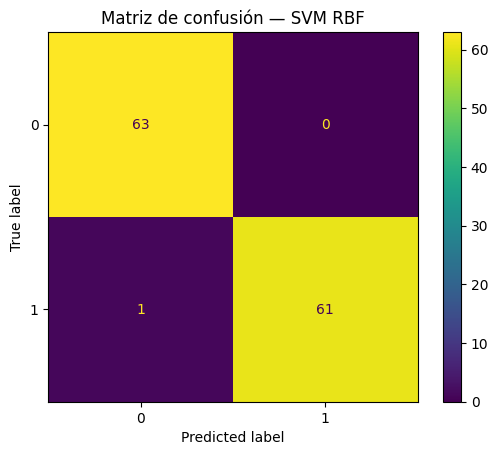

In [20]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test_moon,
        best_predictions,
    ),
).plot()

plt.title("Matriz de confusión — SVM RBF")
plt.show()


In [21]:
pd.DataFrame({
    "Métrica": ["Accuracy", "F1", "ROC-AUC"],
    "Valor": [
        accuracy_score(
            y_test_moon,
            best_predictions,
        ),
        f1_score(
            y_test_moon,
            best_predictions,
        ),
        roc_auc_score(
            y_test_moon,
            best_probabilities,
        ),
    ],
})


,Métrica,Valor
0,Accuracy,0.9920
1,F1,0.9919
2,ROC-AUC,0.9997


## 15. Probabilidades en SVC

`SVC(probability=True)` habilita probabilidades mediante un procedimiento adicional de calibración interna.

Esto:

- incrementa el costo de entrenamiento;
- no garantiza probabilidades perfectamente calibradas;
- debe evaluarse por separado cuando las probabilidades sean importantes.

## 16. Ventajas y limitaciones

### Ventajas

- funciona bien en espacios de alta dimensión;
- puede producir fronteras no lineales muy flexibles;
- utiliza solo vectores de soporte para definir la solución;
- ofrece control explícito de regularización.

### Limitaciones

- requiere escalamiento;
- puede ser costosa con datasets grandes;
- los hiperparámetros interactúan;
- la interpretación es limitada con kernels no lineales;
- no produce probabilidades directamente de forma natural;
- puede ser sensible a ruido y outliers.

## 17. Errores frecuentes

1. Usar SVM sin escalar.
2. Interpretar \(C\) como número de clusters o clases.
3. Suponer que un kernel más complejo siempre mejora.
4. Elegir \(C\) y \(\gamma\) con test.
5. Confundir vectores de soporte con centroides.
6. Usar RBF sin revisar overfitting.
7. Habilitar `probability=True` sin necesidad.
8. Ignorar el costo computacional en muestras grandes.
9. Comparar fronteras usando escalas distintas.
10. Interpretar una SVM no lineal como un modelo fácilmente explicable.

## 18. Experimentos sugeridos

### Experimento 1

Varía \(C\) en una escala logarítmica.

### Experimento 2

Varía \(\gamma\) y observa la complejidad de la frontera.

### Experimento 3

Cambia el grado del kernel polinomial.

### Experimento 4

Aumenta el ruido de `make_moons`.

### Experimento 5

Compara SVM con regresión logística.

### Experimento 6

Agrega outliers cercanos al margen.

### Experimento 7

Compara accuracy train-test para detectar overfitting.

### Experimento 8

Usa `GridSearchCV` para seleccionar \(C\), \(\gamma\) y kernel.

### Experimento 9

Mide el tiempo de entrenamiento al aumentar el tamaño de muestra.

### Experimento 10

Compara resultados con y sin `StandardScaler`.

## 19. Resumen

En este notebook:

- ajustamos una SVM lineal;
- visualizamos margen y vectores de soporte;
- estudiamos el efecto de \(C\);
- mostramos la importancia del escalamiento;
- comparamos kernels lineal, polinomial y RBF;
- analizamos el efecto de \(\gamma\);
- estudiamos la interacción entre \(C\) y \(\gamma\);
- resolvimos patrones no lineales con lunas y círculos;
- evaluamos el modelo con métricas de clasificación.

Las SVM combinan regularización, geometría y kernels para construir fronteras flexibles. Su buen desempeño depende de un preprocesamiento correcto y de una selección cuidadosa de hiperparámetros.